ZOMATO Restaurant Analysis


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
d1 = pd.read_csv("zomato.csv", encoding='ISO-8859-1')
country_code = pd.read_excel("Country-Code.xlsx")
d1.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [20]:
data=pd.merge(d1,country_code,how='left',on='Country Code')

In [21]:
#checking missing values
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [37]:
data['Cuisines'] =data['Cuisines'].fillna('unknown')
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

**Exploratory Analysis and Visualization**
before we ask question on dataset it woluld be helpful to understand the restaurent geographical spread  understand the rating currency online delivery city  coverage etc 

In [38]:
cusine_counts.head(10)

,Cuisines,counts
0,"North Indian, Chinese, Italian, Continental",2
1,"Continental, Italian, Asian, Indian",1
2,Ice Cream,1
3,North Indian,1
4,"North Indian, Italian, Asian, American",1
5,"North Indian, Chinese, Continental, Italian",1
6,"North Indian, Chinese",1
7,"Biryani, North Indian, Hyderabadi",1
8,"Biryani, Hyderabadi",1
9,"North Indian, Chinese, Italian, American, Midd...",1


In [22]:
print("let us  seee how many country include in this surway")
for i in pd.unique(data.Country): print(i)
print()

print("total  nuber of country in this surway " , data['Country'].nunique())

let us  seee how many country include in this surway
Phillipines
Brazil
United States
Australia
Canada
Singapore
UAE
India
Indonesia
New Zealand
United Kingdom
Qatar
South Africa
Sri Lanka
Turkey

total  nuber of country in this surway  15


## **this survey shows that zomato is spread over 15 counties and zomato is multinational comapny and it has busness in these countries 

# now let us understand about  ratings 

In [23]:
data2=data.groupby(['Aggregate rating','Rating color','Rating text']).size().reset_index().rename(columns={0:'rateing_count'})
data2

,Aggregate rating,Rating color,Rating text,rateing_count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


as above we  understand the relationship between the Aggregate rating,Rating color,Rating text  and we see that  rating  betweens 
-->0.0 = white 
---
-->1.8 - 2.4 = Red
---
-->2.5 - 3.4 = Orange
---
-->3.5 - 3.9 = Yellow
---
-->4.0 - 4.4 = Green
---
-->4.5 - 4.9 = Dark Green
---

In [24]:
## **country and currency **

In [25]:
country_with_currency=data.groupby(['Country','Currency']).size().reset_index(name='count')
country_with_currency.drop(columns=['count'], inplace=True)
country_with_currency

,Country,Currency
0,Australia,Dollar($)
1,Brazil,Brazilian Real(R$)
2,Canada,Dollar($)
3,India,Indian Rupees(Rs.)
4,Indonesia,Indonesian Rupiah(IDR)
5,New Zealand,NewZealand($)
6,Phillipines,Botswana Pula(P)
7,Qatar,Qatari Rial(QR)
8,Singapore,Dollar($)
9,South Africa,Rand(R)


**here we see that dollar is used for payment in online food order
majorly 4 country used dollors**

# **here we have some specific questions and try to answer them using data frame operations and visualizations.**

## **Q1: Which localitynin New Delhi has the highest number of restaurant listedon Zomato?

Text(0.5, 1.0, 'Resturents ')

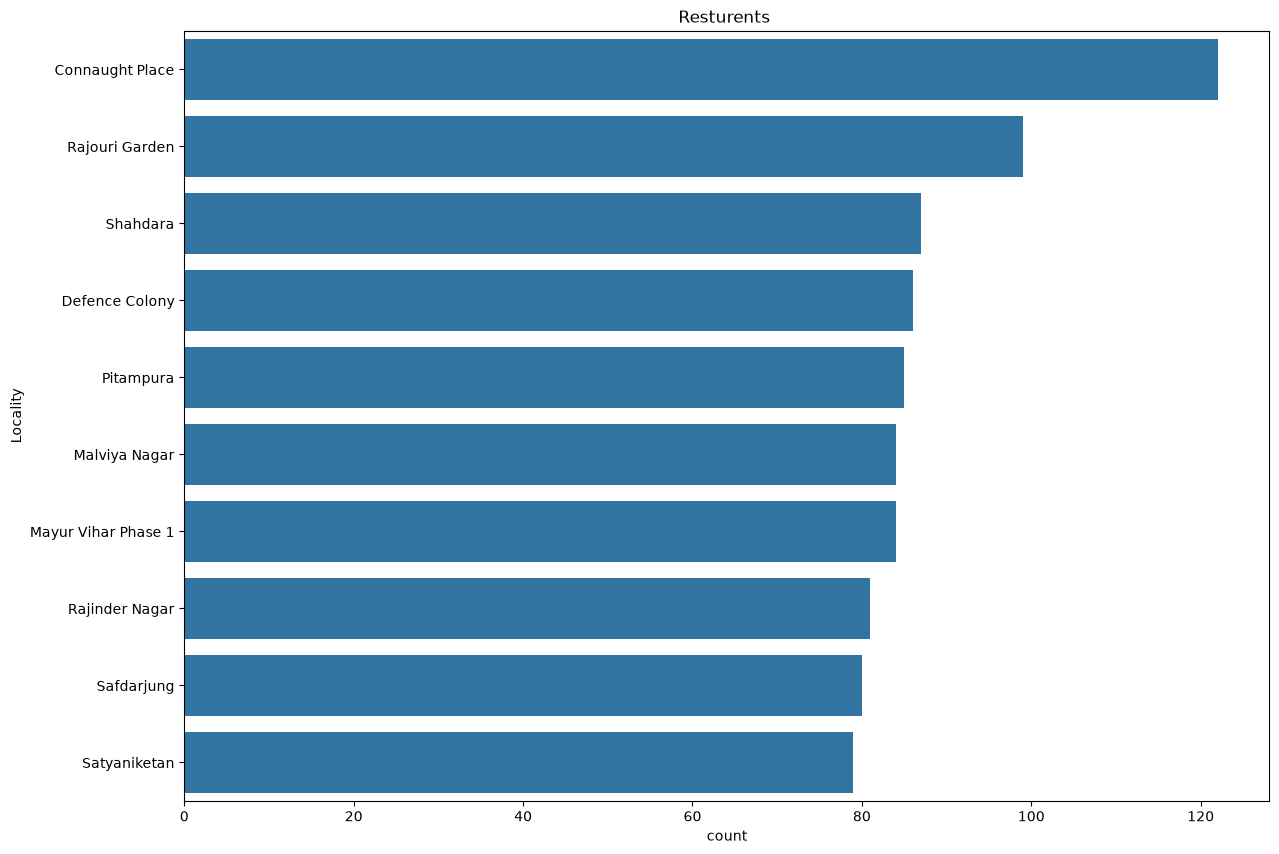

In [26]:
Delhi=data[(data.City=='New Delhi')]
plt.figure(figsize=(14,10))
sns.barplot(x=Delhi.Locality.value_counts().head(10),y=Delhi.Locality.value_counts().head(10).index)
plt.title('Resturents ')

# Here we seems that connaught place has maximum no of restaurants 

Q2 What types of cuisine do these highly rated restuarants offer?

In [27]:
data.Cuisines.value_counts()

Cuisines
North Indian                          936
North Indian, Chinese                 511
Chinese                               354
Fast Food                             354
North Indian, Mughlai                 334
                                     ... 
Restaurant Cafe, Turkish, Desserts      1
Desserts, Bí_rek                        1
Burger, Izgara                          1
World Cuisine, Patisserie, Cafe         1
Italian, World Cuisine                  1
Name: count, Length: 1825, dtype: int64

In [33]:
good_restaurant = Delhi[( Delhi['Locality'] == 'Connaught Place' ) & ( Delhi['Rating text'] .isin(['Excellent','Very Good']) )]
cusine_counts = good_restaurant['Cuisines'].value_counts().rename_axis('Cuisines').reset_index(name='counts')

## Q3: How many of such restaurants accept online delivery

<Axes: title={'center': 'Resturants Online Delivery'}, xlabel='count', ylabel='Locality'>

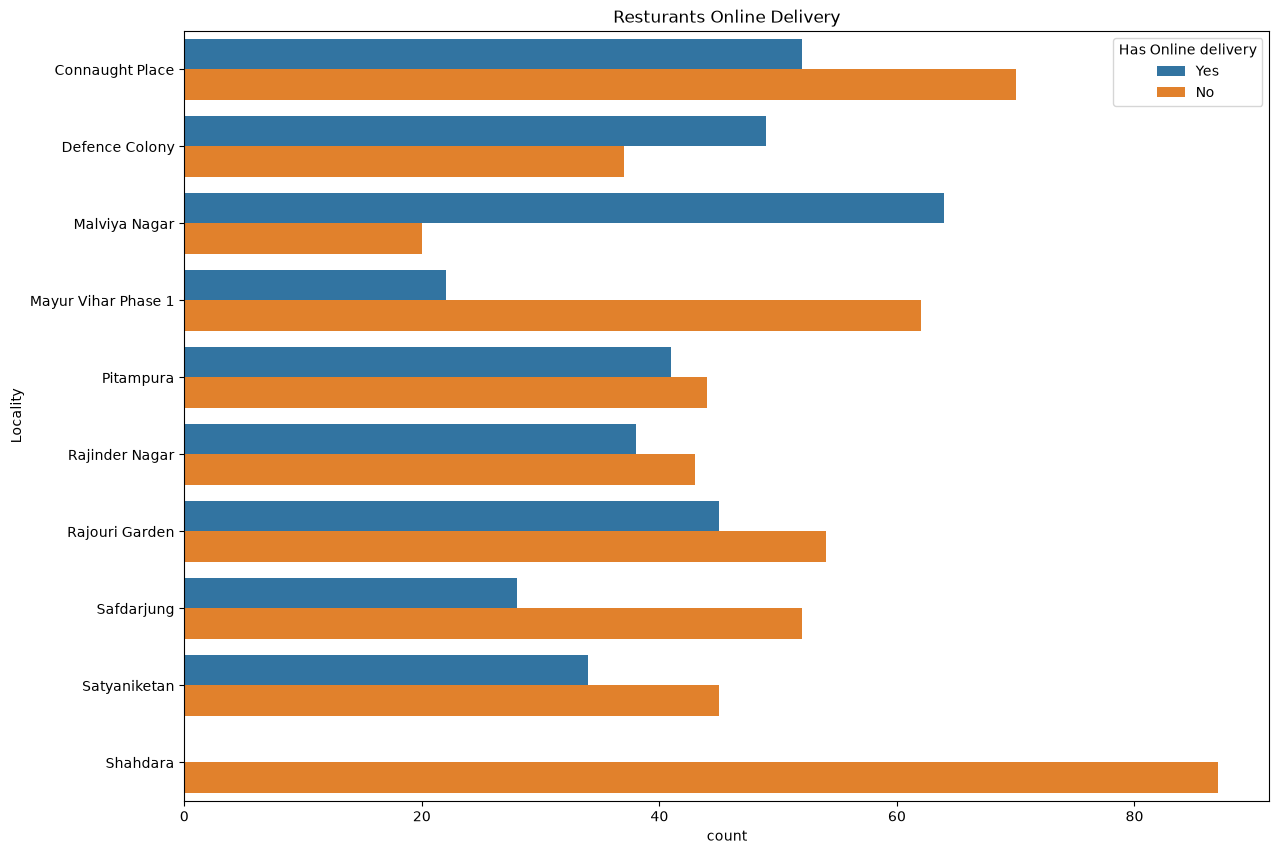

In [36]:
top_locality=Delhi.Locality.value_counts().head(10)
plt.figure(figsize=(14,10))
plt.title('Resturants Online Delivery')
sns.countplot(y="Locality", data=Delhi[Delhi.Locality.isin(top_locality.index)],hue='Has Online delivery')

here we seen that expect shadara  every place has online delivery 

CONCLUSION
This project analyzed Zomato restaurant data across 15 countries. The analysis examined restaurant ratings, cuisines, currencies, locations, and online-delivery availability. North Indian was the most common cuisine, and Connaught Place had the highest number of restaurants among the New Delhi localities analyzed. Online-delivery availability varied by location, with some areas offering the service more frequently than others. Overall, the project shows how restaurant preferences and services differ across locations.